# Extraction des données OBT

In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
from sqlalchemy import create_engine

# Charger le fichier .env
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = "5433"
database = os.getenv("DB_NAME")

schema = os.getenv("DB_SCHEMA")
table = os.getenv("DB_TABLE")

# Connexion PostgreSQL

engine = create_engine(
    f"postgresql://{user}:{password}@{host}:{port}/{database}",
)

# Extraction OBT

query = 'SELECT * FROM "ml_schema"."ml_annonces"'

df = pd.read_sql(query, engine)

# Affichage

display(df.head())

print("Dimensions :", df.shape)

# Fermer connexion

engine.dispose()

,titre,ville,quartier,prix,surface,chambres,salles_bain,etage,annee,prix_m2,nb_pieces,surface_par_piece
0,Appartement neuf à vendre à Almaz,Casablanca,Almaz,5852,75.0,2,2.0,2.0,2022,78.026667,4.0,18.750000
1,appartement à vendre ait meloul,Ait Melloul,Toute la ville,5335,85.5,3,2.0,0.0,2016,62.397661,5.0,17.100000
2,Appartement Tanger Balia,Tanger,Tanja Balia,3446,55.0,2,1.0,2.0,2024,62.654545,3.0,18.333333
3,Studio à vendre 38 m² à Casablanca Maarif,Casablanca,Maarif,4613,38.0,1,1.0,2.0,2018,121.394737,2.0,19.000000
4,Appartement à vendre 80 m² à Oujda,Oujda,Boustane,1667,80.0,2,0.0,2.0,2017,20.837500,2.0,40.000000


Dimensions : (495, 12)


# Préparation des données (Post-DB transformations)

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

# 2️-OBT déjà chargé
# df = pd.read_sql(query, engine)


# 3-Séparation features / target

target = "prix"   # بدّلها حسب الداتا ديالك

X = df.drop(columns=[target])
y = df[target]


# 4️-Séparation Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


# 5️-type de colonne 


numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns


# 6️⃣ Pipelines ديال التحضير

# Numeric: missing + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())   # أو MinMaxScaler()
])

# Categorical: missing + encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)



X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape after preprocessing:")
print(X_train_processed.shape)



if len(np.unique(y_train)) < 20:  # شرط تقريبي
    smote = SMOTE(random_state=42)

    X_train_processed, y_train = smote.fit_resample(
        X_train_processed,
        y_train
    )

    print("SMOTE applied ✅")
    print("New training size:", X_train_processed.shape)



print("Data ready for training 🚀")

Train size: (396, 11)
Test size: (99, 11)
Shape after preprocessing:
(396, 557)
Data ready for training 🚀


C:\Users\salli\AppData\Local\Temp\ipykernel_18172\706791371.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


# FEATURE ENGINEERING AVANCÉ

In [3]:


import numpy as np
import pandas as pd

# df = pd.read_sql(query, engine)

# 1️⃣ Log transformation des prix

df["log_prix"] = np.log1p(df["prix"])  # log(1 + prix)

# 2️⃣ Ratios (prix / surface)

df["prix_par_m2"] = df["prix"] / df["surface"]

# 3️⃣ Interaction entre variables

df["surface_x_pieces"] = df["surface"] * df["nb_pieces"]

# 4️⃣ Indicateurs géographiques

# ville

df["ville_code"] = df["ville"].astype("category").cat.codes

# quartier 
if "quartier" in df.columns:
    df["quartier_code"] = df["quartier"].astype("category").cat.codes

# 5️⃣ Variables temporelles

# colonne date
if "date_publication" in df.columns:
    df["date_publication"] = pd.to_datetime(df["date_publication"])

    df["annee"] = df["date_publication"].dt.year
    df["mois"] = df["date_publication"].dt.month
    df["jour"] = df["date_publication"].dt.day

    df["saison"] = df["mois"] % 12 // 3 + 1

# 6️⃣ Vérification

print(df.head())

print("\nNouvelles features ajoutées:")
print(df.columns)

                                       titre        ville        quartier  \
0          Appartement neuf à vendre à Almaz   Casablanca           Almaz   
1            appartement à vendre ait meloul  Ait Melloul  Toute la ville   
2                   Appartement Tanger Balia       Tanger     Tanja Balia   
3  Studio à vendre 38 m² à Casablanca Maarif   Casablanca          Maarif   
4         Appartement à vendre 80 m² à Oujda        Oujda        Boustane   

   prix  surface  chambres  salles_bain  etage  annee     prix_m2  nb_pieces  \
0  5852     75.0         2          2.0    2.0   2022   78.026667        4.0   
1  5335     85.5         3          2.0    0.0   2016   62.397661        5.0   
2  3446     55.0         2          1.0    2.0   2024   62.654545        3.0   
3  4613     38.0         1          1.0    2.0   2018  121.394737        2.0   
4  1667     80.0         2          0.0    2.0   2017   20.837500        2.0   

   surface_par_piece  log_prix  prix_par_m2  surface_x_p

# 📈 MODÈLE DE RÉGRESSION

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Sélection des features

target = "prix"

features = [
    "surface",
    "chambres",
    "salles_bain",
    "etage",
    "nb_pieces",
    "prix_m2",
    "surface_par_piece",
    "log_prix"
]

X = df[features]
y = df[target]

# 2️⃣ Split train / test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3️⃣ Modèle

model_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_reg.fit(X_train, y_train)

# 4️⃣ Prédictions

y_pred = model_reg.predict(X_test)

# 5️⃣ Évaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 RÉGRESSION RESULTS")
print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)

📊 RÉGRESSION RESULTS
MAE : 117.28010101010096
MSE : 306300.90876868664
R²  : 0.9926037103536798


# 🧠 MODÈLE DE CLASSIFICATION

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1️⃣ Création d'une vraie target (IMPORTANT)


df["type_prix"] = pd.qcut(
    df["prix"],
    q=3,
    labels=["bas", "moyen", "haut"]
)

# Encoding
le = LabelEncoder()
df["type_prix_encoded"] = le.fit_transform(df["type_prix"])

# 2️⃣ Features

features_cls = [
    "surface",
    "chambres",
    "salles_bain",
    "etage",
    "nb_pieces",
    "prix_m2"
]

X = df[features_cls]
y = df["type_prix_encoded"]

# 3️⃣ Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4️⃣ Model

model_cls = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_cls.fit(X_train, y_train)

# 5️⃣ Predictions

y_pred = model_cls.predict(X_test)

# 6️⃣ Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("🧠 CLASSIFICATION RESULTS")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)

🧠 CLASSIFICATION RESULTS
Accuracy  : 0.9292929292929293
Precision : 0.9340958605664489
Recall    : 0.9292929292929293
F1-score  : 0.9297528254008125


# 📊ANALYSE DES RÉSULTATS


📌 Feature Importance:
       feature  importance
5      prix_m2    0.561634
0      surface    0.243032
4    nb_pieces    0.066121
3        etage    0.057347
1     chambres    0.038541
2  salles_bain    0.033325


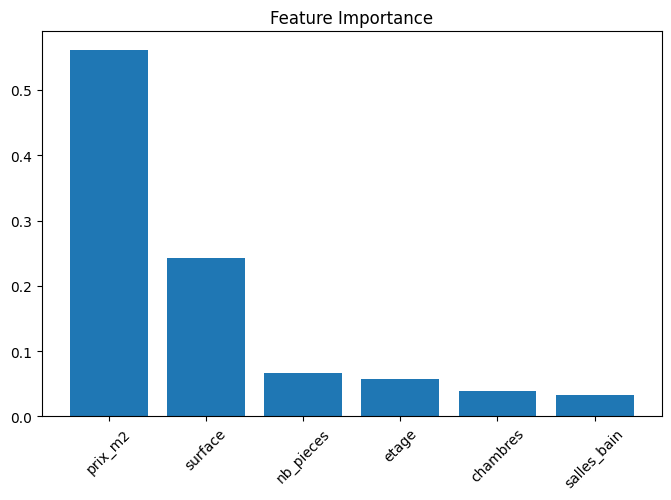


📌 Aperçu des erreurs:
     y_true  y_pred  error
364       1       1      0
452       2       2      0
491       0       2     -2
170       2       2      0
377       1       1      0


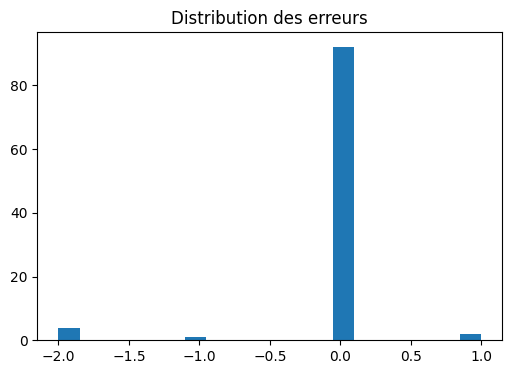


📊 MAE : 0.1111111111111111

📊 COMPARAISON DES MODÈLES
Linear Regression R² : 0.019168067321709392
Random Forest R²     : 0.8442136363636363


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error

# 1️⃣ FEATURE IMPORTANCE

importances = model_cls.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\n📌 Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8,5))
plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# 2️⃣ ERROR ANALYSIS

errors_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

errors_df["error"] = errors_df["y_true"] - errors_df["y_pred"]

print("\n📌 Aperçu des erreurs:")
print(errors_df.head())

plt.figure(figsize=(6,4))
plt.hist(errors_df["error"], bins=20)
plt.title("Distribution des erreurs")
plt.show()

print("\n📊 MAE :", mean_absolute_error(y_test, y_pred))

# 3️⃣ MODEL COMPARISON

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n📊 COMPARAISON DES MODÈLES")

print("Linear Regression R² :", r2_score(y_test, lr_pred))
print("Random Forest R²     :", r2_score(y_test, rf_pred))

# 💻Optimisation des modèles

In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1️⃣ Modèle de base

rf = RandomForestClassifier(random_state=42)

# 2️⃣ Hyperparameter Tuning (GridSearchCV)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("📌 Best parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# 3️⃣ Cross Validation

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\n📊 Cross Validation Scores:")
print(cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# 4️⃣ Evaluation sur Test

y_pred = best_model.predict(X_test)

print("\n📊 Test Accuracy:", accuracy_score(y_test, y_pred))

# 5️⃣ Feature Improvement (importance)

importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\n📌 Feature Importance:")
print(feature_importance)

# 6️⃣ Overfitting Check

train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("\n📊 Overfitting Check:")
print("Train Score:", train_score)
print("Test Score :", test_score)

if train_score - test_score > 0.1:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is stable")

📌 Best parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

📊 Cross Validation Scores:
[0.925      0.93670886 0.88607595 0.92405063 0.97468354]
Mean CV Accuracy: 0.9293037974683545

📊 Test Accuracy: 0.9393939393939394

📌 Feature Importance:
       feature  importance
5      prix_m2    0.580543
0      surface    0.229536
4    nb_pieces    0.072180
3        etage    0.050644
1     chambres    0.039916
2  salles_bain    0.027181

📊 Overfitting Check:
Train Score: 0.9873737373737373
Test Score : 0.9393939393939394
✅ Model is stable


In [8]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 1️⃣ RECHARGEMENT OBT (re-exécution automatique)

# df = pd.read_sql(query, engine)  # OBT source

# 2️⃣ Création de la target

df["type_prix"] = pd.qcut(
    df["prix"],
    q=3,
    labels=["bas", "moyen", "haut"]
)

le = LabelEncoder()
df["type_prix_encoded"] = le.fit_transform(df["type_prix"])

# 3️⃣ Features / Target

features = [
    "surface",
    "chambres",
    "salles_bain",
    "etage",
    "nb_pieces",
    "prix_m2"
]

X = df[features]
y = df["type_prix_encoded"]

# 4️⃣ Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5️⃣ Preprocessing Pipeline

numeric_features = X.columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

# 6️⃣ Modèle final (Pipeline complet)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# 7️⃣ Training
pipeline.fit(X_train, y_train)

# 8️⃣ Cross Validation

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("📊 CV Mean Accuracy:", cv_scores.mean())

# 9️⃣ Evaluation

print("Train Score:", pipeline.score(X_train, y_train))
print("Test Score :", pipeline.score(X_test, y_test))

# 🔟 EXPORT DU MODÈLE (important)

joblib.dump(pipeline, "ml_pipeline_model.pkl")

print("✅ Model saved successfully!")


📊 CV Mean Accuracy: 0.9166772151898733
Train Score: 1.0
Test Score : 0.9292929292929293
✅ Model saved successfully!
